# **ML Model:** Logistic Regression

## **Notes:**

**Logistic regression** model will serve as **baseline model** in this project.

His purpose is to provide **reference point** which will be used to evaluate **advanced models**. It is commonly used for this because of its efficiency, simplicity, strong performance on many classification task.

Results that are obtained here will later be compared with more advanced (complex) models in this project:
- **Random Forest** (RF)
- **eXtreme Gradient Boosting** (XGBoost)

## **Implementation:**

#### Librabry imports

In [ ]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

In [2]:
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

In [3]:
from utils import eval_model, print_report, save_results, load_results, load_info, split_info # type: ignore

### **Load data**

In [4]:
data = pd.read_excel('../data/processed/accident_processed_srb.xlsx')

In [5]:
load_info(df=data)

Shape: (205352, 16)
Columns: ['municipality', 'longitude', 'latitude', 'accident_type', 'month', 'day_of_week', 'hour', 'day_type', 'is_rush', 'is_night', 'season', 'acc_parked_vehicles', 'acc_pedestrians', 'acc_single_vehicle', 'acc_two_vehicles_no_turn', 'acc_two_vehicles_turn_or_cross']
Number of coumnts: 16
Target distribution: accident_type
0    0.597
1    0.403
Name: proportion, dtype: float64


In [6]:
y = data['accident_type']
X = data.drop(columns=['accident_type'])

### **Split data**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
split_info(X_train, X_test, y_train, y_test)

Rows number (Train): 164281
Rows number (Test): 41071
Target distribution (Train): {0: 0.597, 1: 0.403}
Target distribution (Test): {0: 0.597, 1: 0.403}


#### Target Encoding

In [9]:
mun_encoder = ce.TargetEncoder(cols=['municipality'])

In [10]:
X_train['municipality'] = mun_encoder.fit_transform(X_train['municipality'], y_train)
X_test['municipality'] = mun_encoder.transform(X_test['municipality'])

#### Scaling features

Each feature gets value of mean set to 0 and value of std. set to 1.

In [11]:
sc = StandardScaler()

##### Data before scaling

In [12]:
X_train.head()

,municipality,longitude,latitude,month,day_of_week,hour,day_type,is_rush,is_night,season,acc_parked_vehicles,acc_pedestrians,acc_single_vehicle,acc_two_vehicles_no_turn,acc_two_vehicles_turn_or_cross
175803,0.266285,20.393045,44.840774,10,4,13,1,0,0,3,0,0,0,1,0
100351,0.239874,20.404830,44.814717,2,6,13,0,0,0,0,0,0,0,0,1
167577,0.424613,20.241943,44.662004,9,1,20,1,0,0,3,0,0,0,0,1
89852,0.613055,20.644826,44.871233,5,2,17,1,1,0,1,0,0,0,1,0
127493,0.566962,19.651931,46.124863,9,1,12,1,0,0,3,0,0,0,0,1


In [13]:
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

##### Data after scaling

In [14]:
X_train_sc_prev = pd.DataFrame(X_test_sc, columns=X_train.columns)
X_train_sc_prev.head()

,municipality,longitude,latitude,month,day_of_week,hour,day_type,is_rush,is_night,season,acc_parked_vehicles,acc_pedestrians,acc_single_vehicle,acc_two_vehicles_no_turn,acc_two_vehicles_turn_or_cross
0,-1.256728,-0.097851,-0.043303,-1.027986,-1.498173,-0.788266,0.600318,-0.607301,-0.459982,-0.456405,-0.422156,3.451395,-0.536716,-0.661832,-0.566654
1,-1.358207,-0.097851,-0.043303,1.563430,1.046974,0.105250,-1.665785,-0.607301,-0.459982,-1.343518,-0.422156,-0.289738,-0.536716,-0.661832,1.764746
2,0.725591,-0.097851,-0.043303,-0.164181,-0.989143,-1.145673,0.600318,1.646630,-0.459982,0.430707,-0.422156,-0.289738,-0.536716,-0.661832,1.764746
3,0.820940,-0.097851,-0.043303,0.699625,0.028915,-1.145673,0.600318,1.646630,-0.459982,1.317819,2.368791,-0.289738,-0.536716,-0.661832,-0.566654
4,-1.169594,-0.097851,-0.043303,0.411690,-0.480114,-0.073453,0.600318,-0.607301,-0.459982,0.430707,-0.422156,-0.289738,-0.536716,1.510958,-0.566654


### **Training**

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

In [16]:
lr_model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### **Evaluation**

In [17]:
y_pred = lr_model.predict(X_test_sc)
y_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]

In [19]:
results = eval_model(
    model_name = 'Logistic Regression (Baseline)',
    y_test = y_test,
    y_pred = y_pred, 
    y_pred_prob = y_pred_prob,
    target_names = ['Material', 'Injured/Dead']
)

In [20]:
print_report(
    y_test = y_test, 
    y_pred = y_pred, 
    results = results, 
    target_names = ['Material', 'Injured/Dead']
)

Logistic Regression (Baseline)
              precision    recall  f1-score   support

    Material       0.79      0.72      0.75     24509
Injured/Dead       0.63      0.71      0.67     16562

    accuracy                           0.72     41071
   macro avg       0.71      0.72      0.71     41071
weighted avg       0.72      0.72      0.72     41071

ROC-AUC value: 0.7925


### **Additional:**

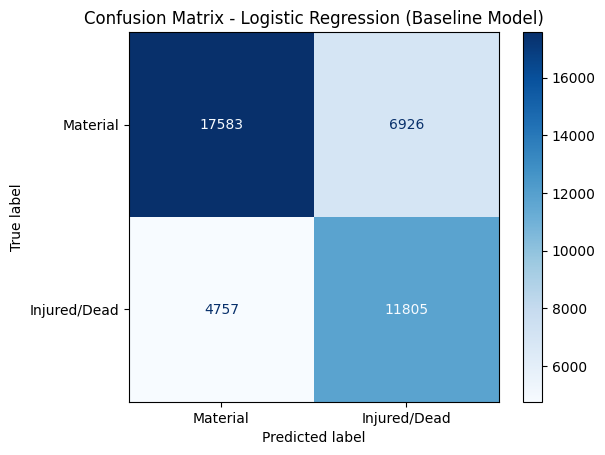

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Material', 'Injured/Dead'], cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Baseline Model)")
plt.show()

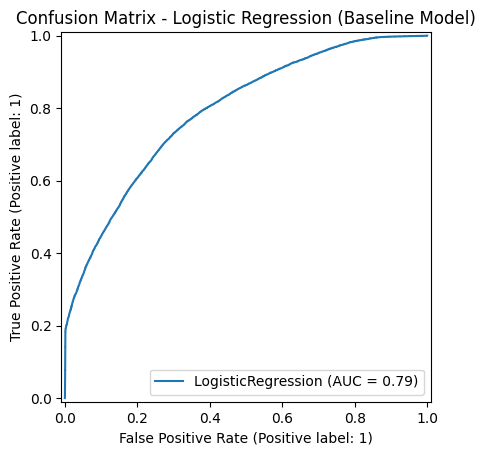

In [ ]:
RocCurveDisplay.from_estimator(lr_model, X_test_sc, y_test)
plt.title("Confusion Matrix - Logistic Regression (Baseline Model)")
plt.show()

In [21]:
save_results(results)

In [ ]:
joblib.dump(lr_model, '../models/logistic_regression_baseline.pkl')
joblib.dump(sc, '../models/scalers/lr_standard_scaler.pkl')
joblib.dump(mun_encoder, '../models/encoders/lr_mun_target_encoder.pkl')